# Task 3: Car Price Prediction with Machine Learning

**CodeAlpha Data Science Internship**

**Objective:** Predict the price of a car using features such as brand, engine specifications,
horsepower, fuel economy (mileage), body type, and more.

**Dataset:** `CarPrice_Assignment.csv` — 205 cars with 26 features including brand/model name,
engine details, dimensions, and price (target variable).

**Workflow:**
1. Load the dataset
2. Explore the data (EDA)
3. Feature engineering & preprocessing
4. Train a regression model
5. Evaluate model performance


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline


## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/CarPrice_Assignment.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [4]:
# Check for missing values
df.isnull().sum().sum()


np.int64(0)

In [5]:
df.describe()


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


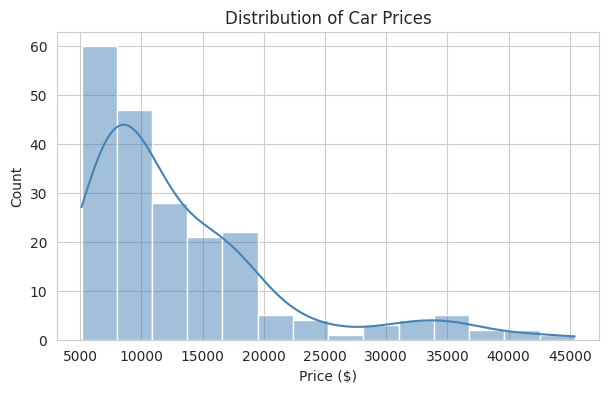

In [6]:
# Distribution of the target variable: price
plt.figure(figsize=(7, 4))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.show()


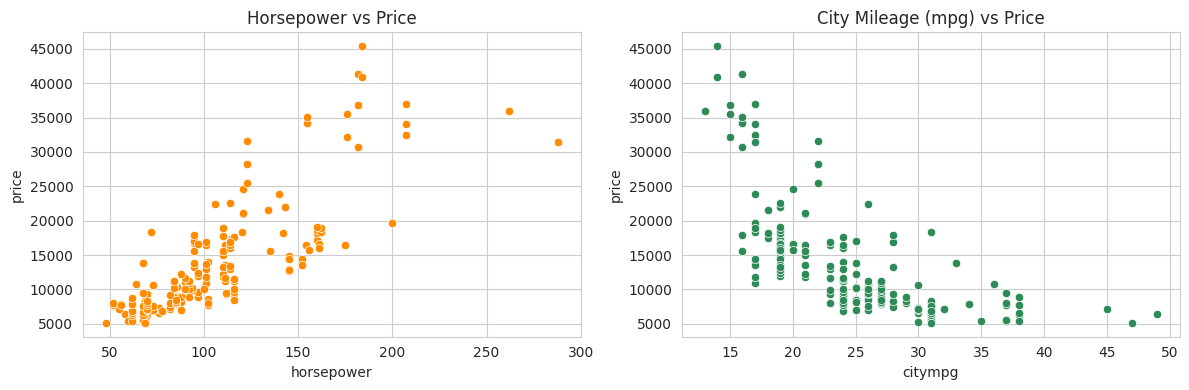

In [7]:
# Relationship between horsepower / engine size and price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(x='horsepower', y='price', data=df, ax=axes[0], color='darkorange')
axes[0].set_title('Horsepower vs Price')

sns.scatterplot(x='citympg', y='price', data=df, ax=axes[1], color='seagreen')
axes[1].set_title('City Mileage (mpg) vs Price')
plt.tight_layout()
plt.show()


## 4. Feature Engineering

- Extract the **car brand** ("brand goodwill" proxy) from the `CarName` column, which originally
  contains the brand and model together (e.g. "alfa-romero giulia" -> "alfa-romero").
- Fix a few inconsistent/misspelled brand names.
- Drop identifier columns that carry no predictive value (`car_ID`, `CarName`).
- One-hot encode categorical features so the model can use them.


In [8]:
# Extract brand name (first word of CarName)
df['brand'] = df['CarName'].str.lower().str.split(' ').str[0]

# Fix inconsistent brand naming
brand_fixes = {
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'nissan': 'nissan'
}
df['brand'] = df['brand'].replace(brand_fixes)

print(f"Number of unique brands: {df['brand'].nunique()}")
df['brand'].value_counts()


Number of unique brands: 22


brand
toyota         32
nissan         18
mazda          17
honda          13
mitsubishi     13
subaru         12
volkswagen     12
peugeot        11
volvo          11
dodge           9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
alfa-romero     3
chevrolet       3
jaguar          3
renault         2
mercury         1
Name: count, dtype: int64

/tmp/ipykernel_601/3663931772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index, palette='mako')


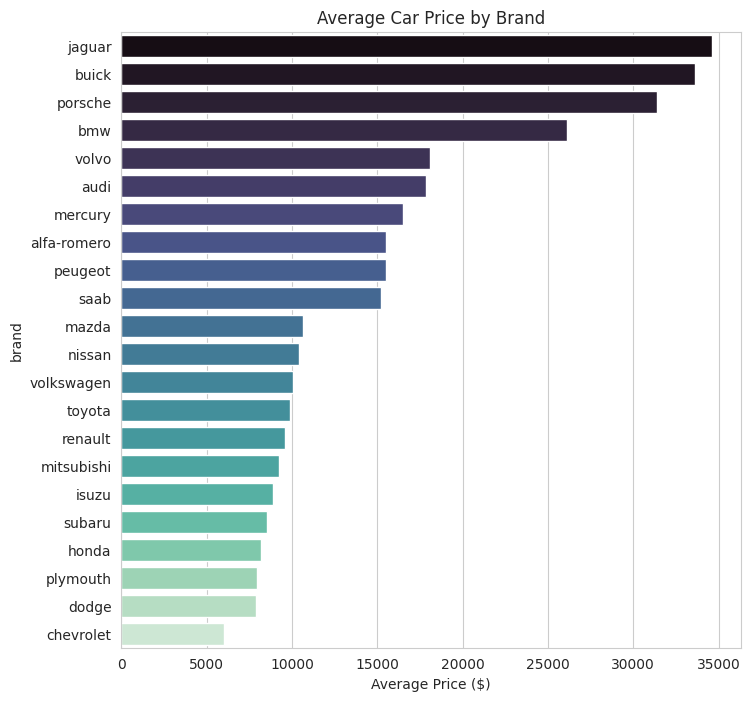

In [9]:
# Average price by brand -- a simple view of "brand goodwill"
brand_avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=brand_avg_price.values, y=brand_avg_price.index, palette='mako')
plt.title('Average Car Price by Brand')
plt.xlabel('Average Price ($)')
plt.show()


In [10]:
# Drop columns that are just identifiers and not useful as predictive features
df_model = df.drop(columns=['car_ID', 'CarName'])

# One-hot encode all remaining categorical columns
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")


Categorical columns to encode: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']
Shape after encoding: (205, 65)


/tmp/ipykernel_601/710799147.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include='object').columns.tolist()


## 5. Train/Test Split & Scaling

In [11]:
X = df_encoded.drop(columns='price')
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Training samples: 164, Test samples: 41


## 6. Model Training

We compare a simple `LinearRegression` baseline with a `RandomForestRegressor`.

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_scaled, y_train)

print("Both models trained successfully.")


Both models trained successfully.


## 7. Model Evaluation

In [13]:
def evaluate(model, name):
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}:")
    print(f"  MAE  = {mae:,.2f}")
    print(f"  RMSE = {rmse:,.2f}")
    print(f"  R2   = {r2:.3f}\n")
    return preds

lin_preds = evaluate(lin_reg, "Linear Regression")
rf_preds = evaluate(rf_reg, "Random Forest Regressor")


Linear Regression:
  MAE  = 1,763.57
  RMSE = 2,669.93
  R2   = 0.910

Random Forest Regressor:
  MAE  = 1,247.93
  RMSE = 1,785.90
  R2   = 0.960



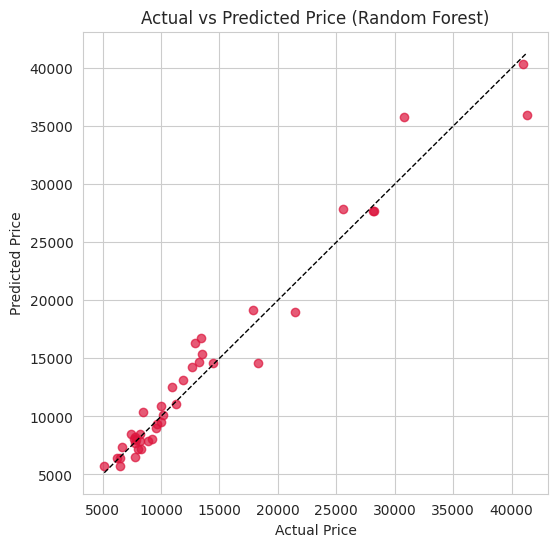

In [14]:
# Actual vs predicted prices (Random Forest)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=1)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.show()


/tmp/ipykernel_601/686982413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='rocket')


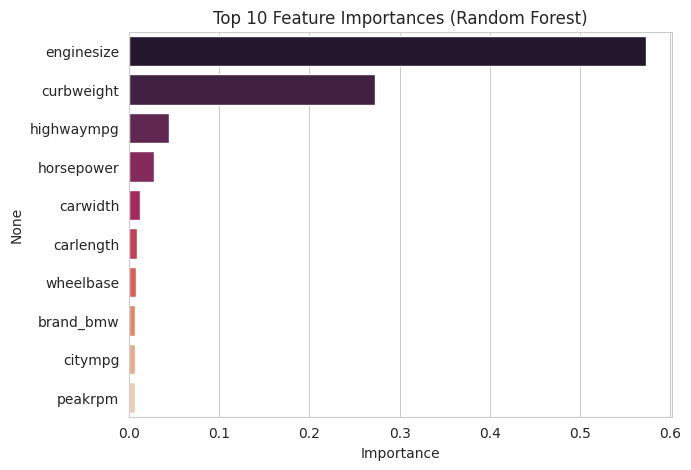

In [15]:
# Top 10 most important features according to the Random Forest model
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, palette='rocket')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


## 8. Conclusion

- The **Random Forest Regressor** outperforms the simple Linear Regression baseline, capturing
  non-linear relationships between car features and price.
- **Engine size**, **curb weight**, and **horsepower** are consistently among the strongest
  predictors of price, along with brand identity.
- These insights could help a manufacturer or dealer estimate a fair market price for a new
  or used vehicle based on its specifications.
